# Telecom X — Previsão de Evasão de Clientes

Este projeto tem como objetivo analisar dados de clientes da Telecom X e construir modelos de Machine Learning capazes de prever a evasão de clientes (churn).

### 1. Preparação dos Dados

Nesta etapa é realizado o carregamento do dataset tratado na etapa anterior do desafio. O objetivo é preparar os dados para aplicação de modelos de Machine Learning, garantindo que estejam organizados e prontos para análise.

### 1.1 Extração do Arquivo Tratado

Nesta etapa é carregado o arquivo CSV contendo os dados já tratados na parte 1 do desafio. Esse dataset já passou por processos de limpeza e organização, permitindo o foco na preparação para modelagem preditiva.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("TelecomX_Dados_Processados.csv")

df.head()

,ID_Cliente,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Provedor_Internet,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Online,Metodo_Pagamento,Valor_Mensal,Valor_Total,Valor_Diario,Total_Servicos
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,0,0,0,0,0,0,One year,1,Mailed check,65.6,593.30,2.19,1
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,0,0,0,0,0,0,Month-to-month,0,Mailed check,59.9,542.40,2.00,1
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,1,0,1,1,0,13,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,98.0,1237.85,3.27,1
4,0013-EXCHZ,1,1,1,1,0,3,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,1


In [4]:
df.shape

(7032, 23)

In [5]:
# informações das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7032 non-null   object 
 1   Evasao                7032 non-null   int64  
 2   Genero                7032 non-null   int64  
 3   Idoso                 7032 non-null   int64  
 4   Parceiro              7032 non-null   int64  
 5   Dependentes           7032 non-null   int64  
 6   Meses_Contrato        7032 non-null   int64  
 7   Servico_Telefone      7032 non-null   int64  
 8   Multiplas_Linhas      7032 non-null   object 
 9   Provedor_Internet     7032 non-null   object 
 10  Seguranca_Online      7032 non-null   int64  
 11  Backup_Online         7032 non-null   int64  
 12  Protecao_Dispositivo  7032 non-null   int64  
 13  Suporte_Tecnico       7032 non-null   int64  
 14  Streaming_TV          7032 non-null   int64  
 15  Streaming_Filmes     

In [6]:
# verificar valores nulos
df.isnull().sum()

,0
ID_Cliente,0
Evasao,0
Genero,0
Idoso,0
Parceiro,0
Dependentes,0
Meses_Contrato,0
Servico_Telefone,0
Multiplas_Linhas,0
Provedor_Internet,0


In [7]:
# verificar duplicatas
df.duplicated().sum()

np.int64(0)

### 1.2 Remoção de Colunas Irrelevantes

Algumas variáveis presentes no dataset não contribuem para o processo de modelagem preditiva. A coluna `ID_Cliente`, por exemplo, representa apenas um identificador único para cada cliente e não possui relação com o comportamento de evasão.

Dessa forma, essa variável é removida para evitar ruído no treinamento dos modelos.

In [8]:
# remover coluna identificadora
df = df.drop(columns=["ID_Cliente"])

# verificar nova dimensão
df.shape

(7032, 22)

In [9]:
# remover duplicatas
df = df.drop_duplicates()

# confirmar remoção
df.duplicated().sum()

np.int64(0)

### 1.3 Validação Rápida do Dataset

Antes da modelagem, são realizadas algumas verificações básicas no dataset para garantir que os dados estejam consistentes e adequados para treinamento de modelos de Machine Learning.

São analisados:

- Valores nulos
- Tipos de dados
- Registros duplicados
- Estatísticas descritivas

In [10]:
# ver valores únicos das variáveis categóricas
df.select_dtypes(include="object").nunique()

,0
Multiplas_Linhas,3
Provedor_Internet,3
Tipo_Contrato,3
Metodo_Pagamento,4


In [11]:
# estatísticas das variáveis numéricas
df.describe()

,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Fatura_Online,Valor_Mensal,Valor_Total,Valor_Diario,Total_Servicos
count,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.0,7010.0,7010.0,7010.0,7010.0,7010.0,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.264907,0.495720,0.162767,0.484023,0.299429,32.520399,0.902996,0.0,0.0,0.0,0.0,0.0,0.0,0.593153,64.888666,2290.353388,2.162907,0.902996
std,0.441315,0.500017,0.369180,0.499780,0.458041,24.520441,0.295985,0.0,0.0,0.0,0.0,0.0,0.0,0.491281,30.064769,2266.820832,1.002245,0.295985
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,18.250000,18.800000,0.610000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,35.750000,408.312500,1.190000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,70.400000,1403.875000,2.350000,1.000000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,56.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,89.900000,3807.837500,3.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,118.750000,8684.800000,3.960000,1.000000


## Encoding das Variáveis Categóricas

Algoritmos de Machine Learning trabalham apenas com valores numéricos.
Portanto, variáveis categóricas precisam ser convertidas para formato numérico.

Neste projeto foi utilizado **One-Hot Encoding**, que cria novas colunas binárias (0 ou 1) para cada categoria existente nas variáveis categóricas.

In [12]:
# 1. Identificar automaticamente quais colunas ainda são texto (object)
colunas_texto = df.select_dtypes(include=['object']).columns.tolist()

# 2. Se houver texto, aplicamos o One-Hot Encoding especificamente nelas
if colunas_texto:
    print(f"Convertendo as seguintes colunas de texto: {colunas_texto}")
    df = pd.get_dummies(df, columns=colunas_texto, drop_first=True)

# 3. Agora que tudo é número ou booleano (True/False), convertemos para Inteiro (0/1)
# Usamos o 'int' para garantir que os modelos matemáticos funcionem perfeitamente
df = df.astype(int)

print("\nSucesso! Agora todos os dados são numéricos.")
print(f"Nova forma do dataset: {df.shape}")
df.head()

Convertendo as seguintes colunas de texto: ['Multiplas_Linhas', 'Provedor_Internet', 'Tipo_Contrato', 'Metodo_Pagamento']

Sucesso! Agora todos os dados são numéricos.
Nova forma do dataset: (7010, 27)


,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Fatura_Online,Valor_Mensal,Valor_Total,Valor_Diario,Total_Servicos,Multiplas_Linhas_1,Multiplas_Linhas_No phone service,Provedor_Internet_DSL,Provedor_Internet_Fiber optic,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pagamento_Credit card (automatic),Metodo_Pagamento_Electronic check,Metodo_Pagamento_Mailed check
0,0,1,0,1,1,9,1,0,0,0,0,0,0,1,65,593,2,1,0,0,1,0,1,0,0,0,1
1,0,0,0,0,0,9,1,0,0,0,0,0,0,0,59,542,2,1,1,0,1,0,0,0,0,0,1
2,1,0,0,0,0,4,1,0,0,0,0,0,0,1,73,280,2,1,0,0,0,1,0,0,0,1,0
3,1,0,1,1,0,13,1,0,0,0,0,0,0,1,98,1237,3,1,0,0,0,1,0,0,0,1,0
4,1,1,1,1,0,3,1,0,0,0,0,0,0,1,83,267,2,1,0,0,0,1,0,0,0,0,1


## Distribuição da Variável Alvo

Antes da modelagem é importante verificar a distribuição da variável alvo (`Evasao`).

Isso permite entender se o dataset está balanceado ou se existe predominância de uma das classes.

In [13]:
# distribuição da variável alvo
df["Evasao"].value_counts()

,count
Evasao,
0,5153
1,1857


In [14]:
# proporção das classes
df["Evasao"].value_counts(normalize=True)

,proportion
Evasao,
0,0.735093
1,0.264907




A variável **Evasao** apresenta 5.153 clientes que permaneceram na empresa (**73,5%**) e 1.857 clientes que cancelaram o serviço (**26,5%**).  
Isso indica um **leve desbalanceamento**, com predominância de clientes que não evadiram.

## Distribuição da Evasão de Clientes

A visualização da variável alvo permite compreender a proporção de clientes que permaneceram na empresa e aqueles que cancelaram o serviço.

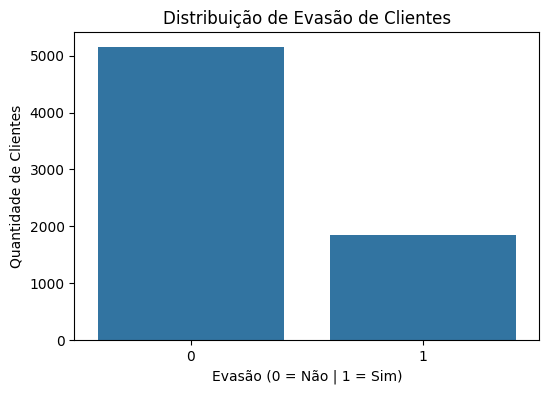

In [15]:
# gráfico de distribuição da evasão
plt.figure(figsize=(6,4))
sns.countplot(x="Evasao", data=df)

plt.title("Distribuição de Evasão de Clientes")
plt.xlabel("Evasão (0 = Não | 1 = Sim)")
plt.ylabel("Quantidade de Clientes")

plt.show()

## Correlação das Variáveis com a Evasão

A análise de correlação permite identificar quais variáveis possuem maior relação com a evasão de clientes. Valores mais próximos de **1 ou -1** indicam uma relação mais forte com a variável alvo.

In [16]:
# calcular correlação com a variável alvo
corr = df.corr()["Evasao"].sort_values(ascending=False)

corr

,Evasao
Evasao,1.000000
Provedor_Internet_Fiber optic,0.307612
Metodo_Pagamento_Electronic check,0.301079
Valor_Diario,0.196361
Valor_Mensal,0.194066
Fatura_Online,0.190518
Idoso,0.151270
Multiplas_Linhas_1,0.041888
Total_Servicos,0.011072
Servico_Telefone,0.011072


In [17]:
df.nunique()

,0
Evasao,2
Genero,2
Idoso,2
Parceiro,2
Dependentes,2
Meses_Contrato,72
Servico_Telefone,2
Seguranca_Online,1
Backup_Online,1
Protecao_Dispositivo,1


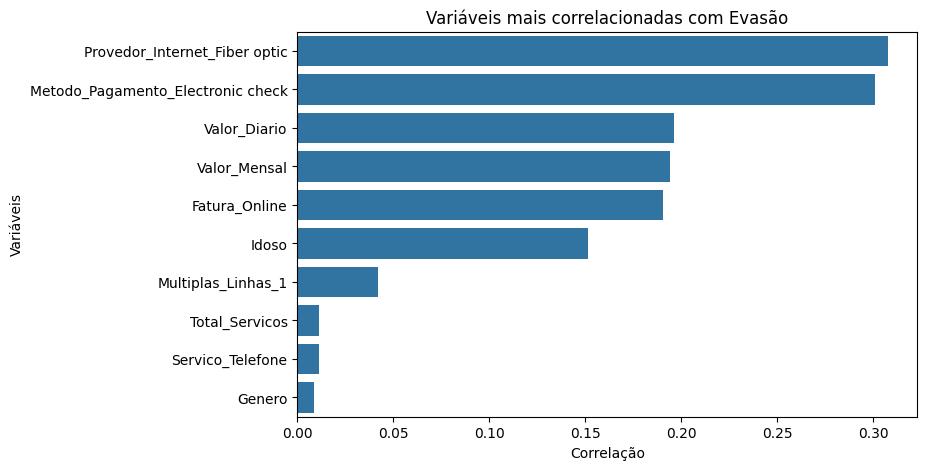

In [18]:
# pegar as 10 variáveis mais correlacionadas
top_corr = corr.drop("Evasao").head(10)

# gráfico de correlação com churn
plt.figure(figsize=(8,5))
sns.barplot(x=top_corr.values, y=top_corr.index)

plt.title("Variáveis mais correlacionadas com Evasão")
plt.xlabel("Correlação")
plt.ylabel("Variáveis")

plt.show()

### Tratamento de Multicolinearidade

A variável Valor_Diario é derivada diretamente de Valor_Mensal, o que gera multicolinearidade em modelos estatísticos e de machine learning, tornando-os instáveis e dificultando interpretar a importância de cada fator.

Ação: Removemos Valor_Diario, mantendo Valor_Mensal e Valor_Total como representações do gasto imediato e acumulado.

In [19]:
# Removendo a variável redundante identificada na análise de multicolinearidade
df = df.drop(columns=['Valor_Diario'])

print(f"Coluna 'Valor_Diario' removida com sucesso.")

Coluna 'Valor_Diario' removida com sucesso.


### Escalonamento de Atributos

Aplicamos **padronização** nas variáveis numéricas `Meses_Contrato`, `Valor_Mensal` e `Valor_Total` para colocá-las na mesma ordem de grandeza.

Isso evita que variáveis com valores maiores (como `Valor_Total`) tenham peso desproporcional no modelo, permitindo que todas contribuam de forma equilibrada para a previsão.

In [20]:
from sklearn.preprocessing import StandardScaler

# Lista de colunas com escalas distintas
colunas_para_escalonar = ['Meses_Contrato', 'Valor_Mensal', 'Valor_Total']

# Inicialização do scaler
scaler = StandardScaler()

# Aplicação da padronização (Média 0 e Desvio Padrão 1)
df[colunas_para_escalonar] = scaler.fit_transform(df[colunas_para_escalonar])

# Verificação dos primeiros resultados escalonados
print("Escalonamento concluído com sucesso.")
df[colunas_para_escalonar].head()

Escalonamento concluído com sucesso.


,Meses_Contrato,Valor_Mensal,Valor_Total
0,-0.959284,0.019202,-0.748628
1,-0.959284,-0.180362,-0.771128
2,-1.163210,0.285287,-0.886717
3,-0.796144,1.116802,-0.464509
4,-1.203996,0.617893,-0.892452


### Correlação e Seleção de Variáveis

O objetivo desta etapa é identificar quais atributos possuem maior relação com a **evasão de clientes**. Uma boa seleção de variáveis ajuda a simplificar o modelo, reduzir o tempo de treinamento e evitar o aprendizado de ruídos estatísticos.

**Análise de Correlação**

Utilizamos a **matriz de correlação** para medir a força e a direção do relacionamento entre as variáveis numéricas e o alvo `Evasao`.

- Valores próximos de **1** ou **-1** indicam forte relação.
- Valores próximos de **0** indicam pouca influência na previsão do churn.

In [21]:
# Identificando colunas que possuem apenas 1 valor único (nunique == 1)
colunas_constantes = [col for col in df.columns if df[col].nunique() <= 1]

print("Colunas com variância zero detectadas:", colunas_constantes)

# Removendo essas colunas do DataFrame
df = df.drop(columns=colunas_constantes)

# Recalculando a correlação para conferir o novo gráfico
correlacao_limpa = df.corr()

print("Colunas restantes no dataset:", df.shape[1])

Colunas com variância zero detectadas: ['Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes']
Colunas restantes no dataset: 20


Correlação das variáveis com o Churn (Evasao):
Evasao                                      1.000000
Provedor_Internet_Fiber optic               0.307612
Metodo_Pagamento_Electronic check           0.301079
Valor_Mensal                                0.194066
Fatura_Online                               0.190518
Idoso                                       0.151270
Multiplas_Linhas_1                          0.041888
Servico_Telefone                            0.011072
Total_Servicos                              0.011072
Genero                                      0.008694
Multiplas_Linhas_No phone service          -0.011072
Metodo_Pagamento_Mailed check              -0.091649
Provedor_Internet_DSL                      -0.124152
Metodo_Pagamento_Credit card (automatic)   -0.134052
Parceiro                                   -0.148670
Dependentes                                -0.162366
Tipo_Contrato_One year                     -0.177742
Valor_Total                                -0.198363

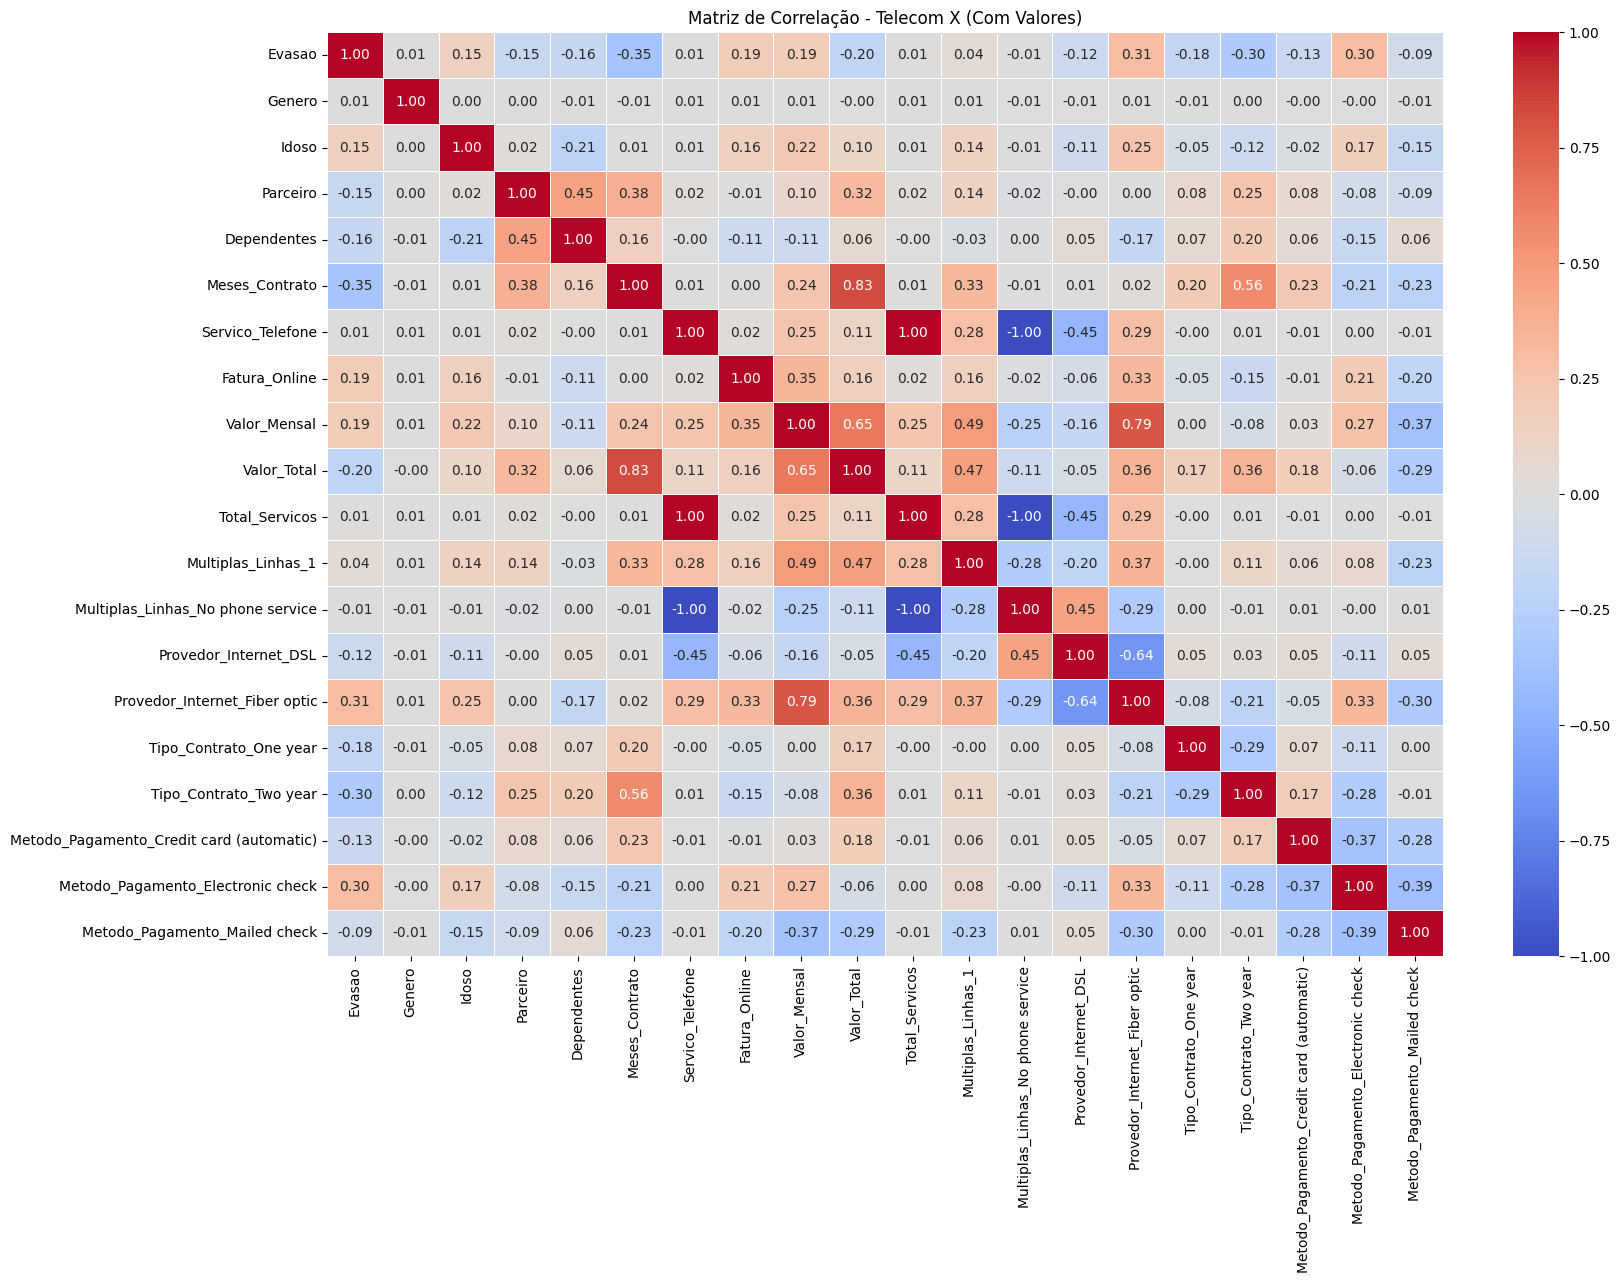

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculando a matriz de correlação
correlacao = df.corr()

# 2. Visualizando a correlação especificamente com a variável alvo 'Evasao'
print("Correlação das variáveis com o Churn (Evasao):")
print(correlacao['Evasao'].sort_values(ascending=False))

# 3. Plotando o Heatmap com valores (duas casas decimais)
# Aumentamos o tamanho da figura para que os números fiquem legíveis
plt.figure(figsize=(18, 12))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação - Telecom X (Com Valores)')
plt.show()

### Análise de Correlação e Seleção de Atributos

A matriz de correlação indica quais variáveis possuem maior relação com a evasão de clientes.

Entre os fatores de **retenção**, destacam-se:
- `Meses_Contrato` (-0.35)
- `Tipo_Contrato_Two year` (-0.30)

Esses resultados indicam que **quanto maior o tempo de permanência e o compromisso contratual, menor a probabilidade de churn**.

Entre os fatores associados ao **maior risco de evasão**, aparecem:
- `InternetService_Fiber optic` (0.31)
- `PaymentMethod_Electronic check` (0.30)

Essas variáveis sugerem maior propensão ao cancelamento e tendem a ser importantes para o modelo identificar clientes com maior risco de churn.

### Análises Direcionadas: Consumo e Fidelidade

Nesta etapa, analisamos as variáveis com maior impacto identificadas na matriz de correlação. Utilizamos **boxplots** para comparar a distribuição dos dados entre clientes ativos e clientes que evadiram, observando diferenças na mediana e nos quartis.

**Tempo de Contrato**
- Avaliamos se a evasão está concentrada em clientes mais novos ou se também ocorre entre clientes com maior tempo de permanência.

**Total Gasto**
- Investigamos se o volume financeiro acumulado funciona como fator de retenção ou se clientes com maior investimento também apresentam cancelamento.

/tmp/ipykernel_41111/4200511667.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao', y='Meses_Contrato', data=df, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_41111/4200511667.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao', y='Valor_Total', data=df, ax=axes[1], palette='magma')


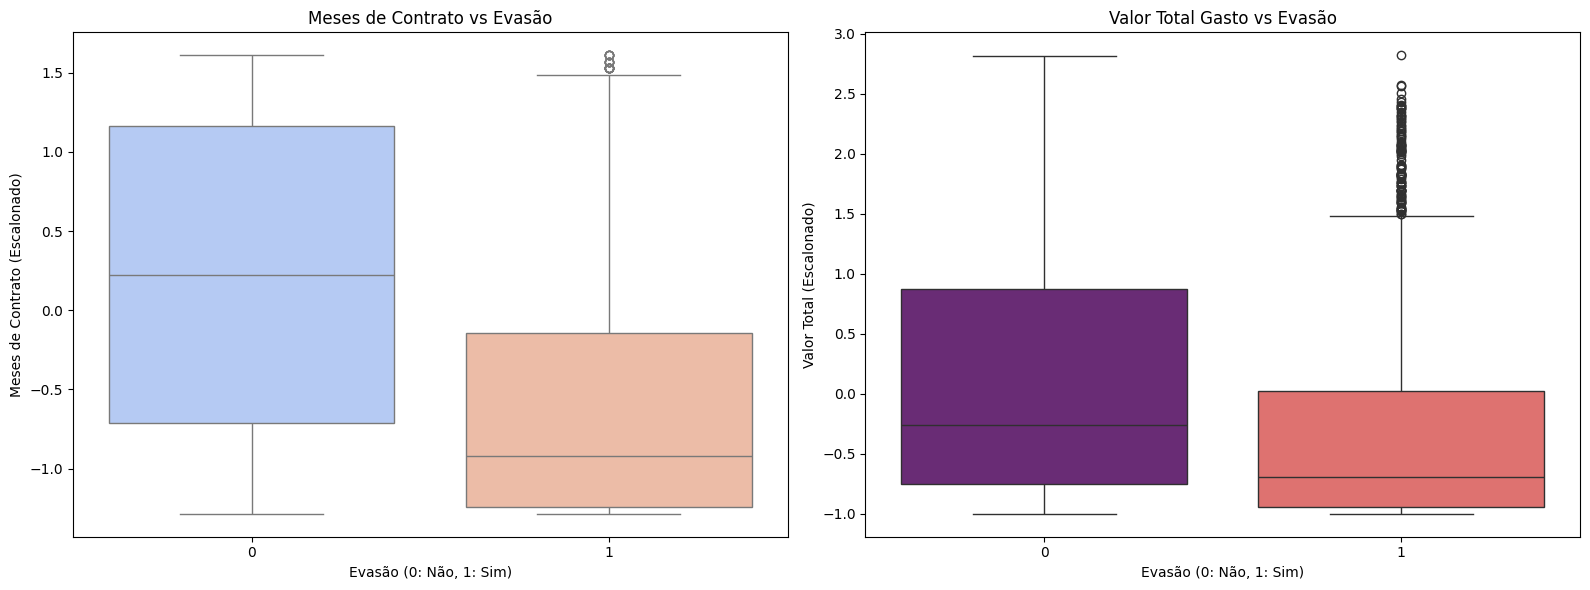

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração da área de plotagem (dois gráficos lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribuição de Meses de Contrato por Evasão
sns.boxplot(x='Evasao', y='Meses_Contrato', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Meses de Contrato vs Evasão')
axes[0].set_xlabel('Evasão (0: Não, 1: Sim)')
axes[0].set_ylabel('Meses de Contrato (Escalonado)')

# 2. Distribuição de Valor Total por Evasão
sns.boxplot(x='Evasao', y='Valor_Total', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Valor Total Gasto vs Evasão')
axes[1].set_xlabel('Evasão (0: Não, 1: Sim)')
axes[1].set_ylabel('Valor Total (Escalonado)')

plt.tight_layout()
plt.show()

### Interpretação dos Padrões de Evasão

A análise com **boxplots** confirma a forte influência do **tempo de relacionamento** no churn da Telecom X.

No gráfico de `Meses_Contrato`, a mediana dos clientes que evadiram é significativamente menor do que a dos clientes que permanecem, indicando que a evasão ocorre principalmente **no início do ciclo de vida do cliente**.

No gráfico de `Valor_Total`, a mediana também é menor entre os clientes que cancelaram, porém com **maior dispersão e presença de outliers**. Isso sugere que, embora clientes com menor gasto acumulado saiam mais, também existe um grupo de clientes com alto investimento que cancela o serviço.

# Modelagem Preditiva: Divisão de Treino e Teste

Para garantir que o modelo seja capaz de **generalizar** — ou seja, prever corretamente dados que nunca viu antes — dividimos o conjunto de dados em duas partes:

**Conjunto de Treino (70%)**  
Funciona como o material de estudo do modelo. Nessa etapa, ele recebe as características (`X`) junto com o resultado real (`y`) e aprende os padrões existentes nos dados.

**Conjunto de Teste (30%)**  
Representa a etapa de avaliação. O modelo recebe apenas as características (`X`) e tenta prever o resultado (`y`). Em seguida, comparamos as previsões com os valores reais para medir o desempenho do modelo.

In [24]:
from sklearn.model_selection import train_test_split

# 1. Separando as variáveis preditoras (X) do alvo (y)
X = df.drop(columns=['Evasao'])
y = df['Evasao']

# 2. Divisão em Treino e Teste (70% Treino e 30% Teste)
# random_state=42 garante que a divisão seja sempre a mesma ao rodar o código
# stratify=y garante que a proporção de 26% de Churn seja mantida em ambos os grupos
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)

print(f"Dados de Treino: {X_train.shape[0]} amostras")
print(f"Dados de Teste: {X_test.shape[0]} amostras")
print("\nProporção de Evasão no Treino:\n", y_train.value_counts(normalize=True))
print("\nProporção de Evasão no Teste:\n", y_test.value_counts(normalize=True))

Dados de Treino: 4907 amostras
Dados de Teste: 2103 amostras

Proporção de Evasão no Treino:
 Evasao
0    0.735072
1    0.264928
Name: proportion, dtype: float64

Proporção de Evasão no Teste:
 Evasao
0    0.73514
1    0.26486
Name: proportion, dtype: float64


### Regressão Logística: O Modelo Base

A **Regressão Logística** é um dos modelos mais utilizados em problemas de **classificação binária** (Sim/Não). Ela estima a probabilidade de um determinado evento ocorrer — neste caso, a **evasão de clientes** — a partir das variáveis de entrada do modelo.

Esse algoritmo é um excelente ponto de partida para análises preditivas porque possui **treinamento rápido**, boa eficiência em conjuntos de dados estruturados e **alta interpretabilidade**. Seus coeficientes permitem entender como cada variável influencia o aumento ou a redução da probabilidade de churn.


In [25]:
from sklearn.linear_model import LogisticRegression

# Inicialização do estimador com limite de iterações expandido para convergência
# max_iter=1000 garante que o algoritmo tenha tempo de convergir para a melhor solução
model_logistico = LogisticRegression(max_iter=1000, random_state=42)

# Treinamento do algoritmo utilizando o conjunto de dados de treino
model_logistico.fit(X_train, y_train)

# Geração de predições com base no conjunto de teste para validação posterior
y_pred_logistico = model_logistico.predict(X_test)

# Cálculo das probabilidades (opcional para análise de threshold)
y_probs_logistico = model_logistico.predict_proba(X_test)[:, 1]

print("Treinamento da Regressão Logística concluído com sucesso.")

Treinamento da Regressão Logística concluído com sucesso.


### Próximo Passo: Avaliação com Matriz de Confusão

A avaliação do modelo é realizada comparando as previsões geradas (`y_pred_logistico`) com os valores reais do conjunto de teste (`y_test`). Esse cruzamento permite verificar o desempenho do modelo na classificação dos clientes.

A **Matriz de Confusão** é uma das ferramentas mais importantes nesse processo, pois apresenta de forma clara quantos casos foram classificados corretamente e onde ocorreram erros de previsão. Para análise de modelos de churn, ela permite identificar especialmente os casos em que o modelo falha ao detectar clientes que realmente irão evadir.
```

<Figure size 800x600 with 0 Axes>

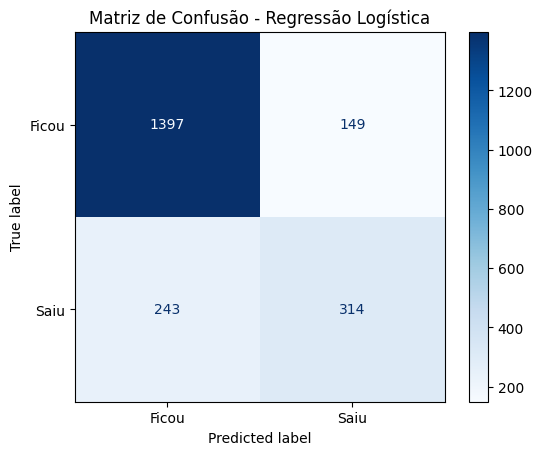


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1546
           1       0.68      0.56      0.62       557

    accuracy                           0.81      2103
   macro avg       0.77      0.73      0.75      2103
weighted avg       0.81      0.81      0.81      2103



In [26]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Geração da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_logistico)

# 2. Visualização Gráfica da Matriz
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ficou', 'Saiu'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - Regressão Logística')
plt.grid(False) # Remove as linhas de grade para clareza
plt.show()

# 3. Relatório Geral de Métricas
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_logistico))

### Modelagem Preditiva: Random Forest (Floresta Aleatória)

O **Random Forest** é um algoritmo de aprendizado por conjunto (*ensemble*) que constrói diversas **árvores de decisão** durante o treinamento. Cada árvore aprende padrões diferentes a partir dos dados, e a predição final do modelo é definida pela **maioria dos votos** entre todas as árvores.

Essa abordagem torna o modelo mais **robusto contra overfitting** e permite capturar **relações não lineares** entre as variáveis explicativas e o Churn. Por essa razão, o Random Forest costuma apresentar bom desempenho em problemas de classificação com múltiplos fatores influenciando o resultado.

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Inicialização do modelo Random Forest
# n_estimators=100 define a criação de 100 árvores de decisão
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinamento do modelo com o conjunto de treino
model_rf.fit(X_train, y_train)

# Execução das predições no conjunto de teste
y_pred_rf = model_rf.predict(X_test)

print("Treinamento do Random Forest concluído.")

Treinamento do Random Forest concluído.


<Figure size 800x600 with 0 Axes>

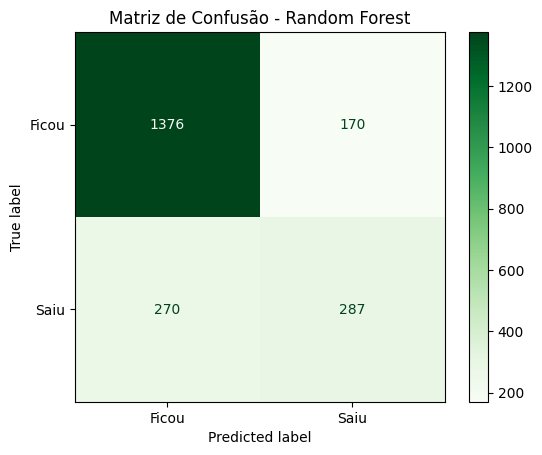


Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1546
           1       0.63      0.52      0.57       557

    accuracy                           0.79      2103
   macro avg       0.73      0.70      0.71      2103
weighted avg       0.78      0.79      0.78      2103



In [28]:
# Geração da Matriz de Confusão para o Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Visualização da Matriz
plt.figure(figsize=(8, 6))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Ficou', 'Saiu'])
disp_rf.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusão - Random Forest')
plt.grid(False)
plt.show()

# Relatório de métricas comparativas
print("\nRelatório de Classificação - Random Forest:")
print(classification_report(y_test, y_pred_rf))

### Balanceamento de Dados com SMOTE

Para reduzir o viés do modelo em direção à **classe majoritária** (clientes que permanecem), foi aplicada a técnica de **sobreamostragem sintética SMOTE** (*Synthetic Minority Over-sampling Technique*). Esse método gera novos exemplos artificiais da classe minoritária (`Evasao = 1`) a partir da similaridade estatística entre os registros existentes.

O objetivo é **equilibrar o conjunto de treinamento**, garantindo que o algoritmo tenha exemplos suficientes para aprender os padrões associados ao cancelamento de clientes. Com isso, espera-se melhorar especialmente a **sensibilidade (Recall)** do modelo, aumentando a capacidade de identificar corretamente os casos de evasão.

In [29]:
!pip install imbalanced-learn

In [30]:
from imblearn.over_sampling import SMOTE

# 1. Instanciando o SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicando o balanceamento APENAS nos dados de TREINO
# Nunca aplique no teste, para não "sujar" a avaliação real
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Antiga distribuição: {y_train.value_counts().to_dict()}")
print(f"Nova distribuição balanceada: {y_train_bal.value_counts().to_dict()}")

# 3. Retreinando a Regressão Logística com os dados equilibrados
model_log_bal = LogisticRegression(max_iter=1000, random_state=42)
model_log_bal.fit(X_train_bal, y_train_bal)

# 4. Novas predições
y_pred_bal = model_log_bal.predict(X_test)

# 5. Conferindo o novo Relatório de Classificação
print("\nRelatório de Classificação (Com SMOTE):")
print(classification_report(y_test, y_pred_bal))

Antiga distribuição: {0: 3607, 1: 1300}
Nova distribuição balanceada: {0: 3607, 1: 3607}

Relatório de Classificação (Com SMOTE):
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1546
           1       0.52      0.80      0.63       557

    accuracy                           0.75      2103
   macro avg       0.71      0.77      0.72      2103
weighted avg       0.81      0.75      0.76      2103



Antiga distribuição: {0: 3607, 1: 1300}
Nova distribuição balanceada: {0: 3607, 1: 3607}

Relatório de Classificação - Experimento SMOTE:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1546
           1       0.52      0.80      0.63       557

    accuracy                           0.75      2103
   macro avg       0.71      0.77      0.72      2103
weighted avg       0.81      0.75      0.76      2103



<Figure size 800x600 with 0 Axes>

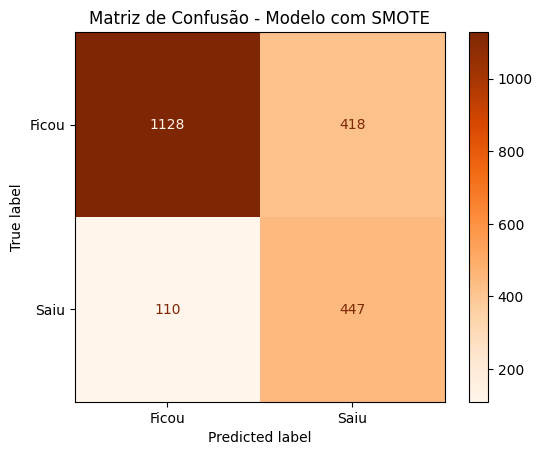

In [31]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instanciação do SMOTE para equilibrar as classes no treino
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Antiga distribuição: {y_train.value_counts().to_dict()}")
print(f"Nova distribuição balanceada: {y_train_bal.value_counts().to_dict()}")

# 3. Criação e treinamento de uma nova instância do modelo
model_logistico_smote = LogisticRegression(max_iter=1000, random_state=42)
model_logistico_smote.fit(X_train_resampled, y_train_resampled)

# 4. Predição utilizando o conjunto de teste original (sem SMOTE)
y_pred_smote = model_logistico_smote.predict(X_test)

# 5. Avaliação dos resultados do experimento
print("\nRelatório de Classificação - Experimento SMOTE:")
print(classification_report(y_test, y_pred_smote))

# 6. Visualização da nova Matriz de Confusão
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['Ficou', 'Saiu'])
disp.plot(cmap='Oranges', values_format='d')
plt.title('Matriz de Confusão - Modelo com SMOTE')
plt.grid(False)
plt.show()

### Conclusões: Balanceamento com SMOTE na Regressão Logística

A aplicação da técnica **SMOTE (Synthetic Minority Over-sampling Technique)** foi importante para reduzir o viés do modelo em relação à classe majoritária. Antes do balanceamento, a regressão logística apresentava dificuldade em identificar casos de evasão devido à menor quantidade de exemplos dessa classe no conjunto de dados.

Com a geração de **dados sintéticos para a classe minoritária** durante o treinamento, o modelo passou a reconhecer melhor os padrões associados ao cancelamento de clientes, aumentando sua capacidade de detectar sinais de churn.

### Análise das Métricas Finais

| Métrica (Classe 1) | Resultado | Impacto no Negócio |
|---|---|---|
| **Recall** | 0.80 | O modelo identifica cerca de 80% dos clientes com probabilidade de evasão. |
| **Precisão** | 0.52 | Aproximadamente metade dos alertas são falsos positivos, exigindo cautela em ações de retenção. |
| **F1-Score** | 0.63 | Indica um equilíbrio razoável entre identificar clientes que irão sair e limitar erros de previsão. |

**Veredito Técnico**

Apesar da queda na **precisão** — um comportamento esperado quando se aumenta a sensibilidade do modelo — o ganho em **Recall** é mais relevante para o contexto de negócio da Telecom X. Em estratégias de retenção, o custo de oferecer um benefício a um cliente que não sairia tende a ser menor do que perder um cliente que poderia ter sido identificado previamente como risco de evasão.

### Duelo Final: Regressão Logística vs. Random Forest (com SMOTE)

Nesta etapa final, o algoritmo **Random Forest** é treinado utilizando o mesmo conjunto de dados balanceado (`X_train_bal`, `y_train_bal`) aplicado anteriormente. O objetivo é avaliar se a capacidade do Random Forest de capturar **relações não lineares** entre as variáveis oferece vantagem em relação à simplicidade da **Regressão Logística**, agora que o problema de desbalanceamento foi tratado com SMOTE.

A comparação entre os dois modelos considera principalmente o equilíbrio entre **Precisão** e **Recall**, métricas essenciais em problemas de churn. A análise busca identificar qual abordagem apresenta maior valor estratégico para apoiar ações de **retenção de clientes da Telecom X**.

=== RELATÓRIO: RANDOM FOREST + SMOTE ===
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1546
           1       0.53      0.61      0.57       557

    accuracy                           0.76      2103
   macro avg       0.69      0.71      0.70      2103
weighted avg       0.77      0.76      0.76      2103



<Figure size 800x600 with 0 Axes>

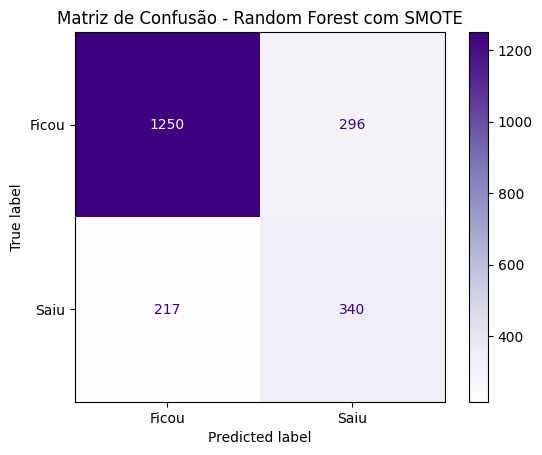

In [32]:
# 1. Instanciando e treinando o Random Forest com os dados balanceados (SMOTE)
model_rf_bal = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_bal.fit(X_train_bal, y_train_bal)

# 2. Realizando as predições no conjunto de teste original
y_pred_rf_bal = model_rf_bal.predict(X_test)

# 3. Exibindo os resultados para o Random Forest com SMOTE
print("=== RELATÓRIO: RANDOM FOREST + SMOTE ===")
print(classification_report(y_test, y_pred_rf_bal))

# 4. Matriz de Confusão para visualização dos erros
cm_rf_bal = confusion_matrix(y_test, y_pred_rf_bal)
plt.figure(figsize=(8, 6))
disp_rf_bal = ConfusionMatrixDisplay(confusion_matrix=cm_rf_bal, display_labels=['Ficou', 'Saiu'])
disp_rf_bal.plot(cmap='Purples', values_format='d')
plt.title('Matriz de Confusão - Random Forest com SMOTE')
plt.grid(False)
plt.show()

### Comparação Final dos Modelos

A comparação entre os modelos indica que, para o problema de churn da Telecom X, a **Regressão Logística balanceada com SMOTE** apresentou desempenho superior ao **Random Forest**.

Apesar de o Random Forest ser um algoritmo robusto e capaz de capturar relações complexas entre variáveis, ele não superou o desempenho do modelo logístico após o balanceamento dos dados.

### Comparativo Técnico

| Métrica (Classe 1) | Regressão Logística + SMOTE | Random Forest + SMOTE | Melhor Resultado |
|---|---|---|---|
| **Recall** | 0.80 | 0.61 | Regressão Logística |
| **Precisão** | 0.52 | 0.53 | Desempenho semelhante |
| **F1-Score** | 0.63 | 0.57 | Regressão Logística |

### Interpretação dos Resultados

O **Recall** da Regressão Logística foi significativamente maior (0.80), indicando que o modelo consegue identificar a maior parte dos clientes com risco de evasão. Já o Random Forest apresentou Recall de 0.61, deixando de identificar uma parcela considerável dos clientes que realmente cancelaram o serviço.

Em conjuntos de dados onde as relações entre variáveis são relativamente diretas — como **tempo de contrato** e **valor mensal** — modelos lineares como a Regressão Logística tendem a apresentar desempenho mais estável. Modelos baseados em árvores, como o Random Forest, podem capturar relações mais complexas, mas também são mais sensíveis a ruídos presentes nos dados.

/tmp/ipykernel_41111/824396038.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variável', data=importancia_log, ax=ax[0], palette='coolwarm')
/tmp/ipykernel_41111/824396038.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importancia_rf, ax=ax[1], palette='viridis')


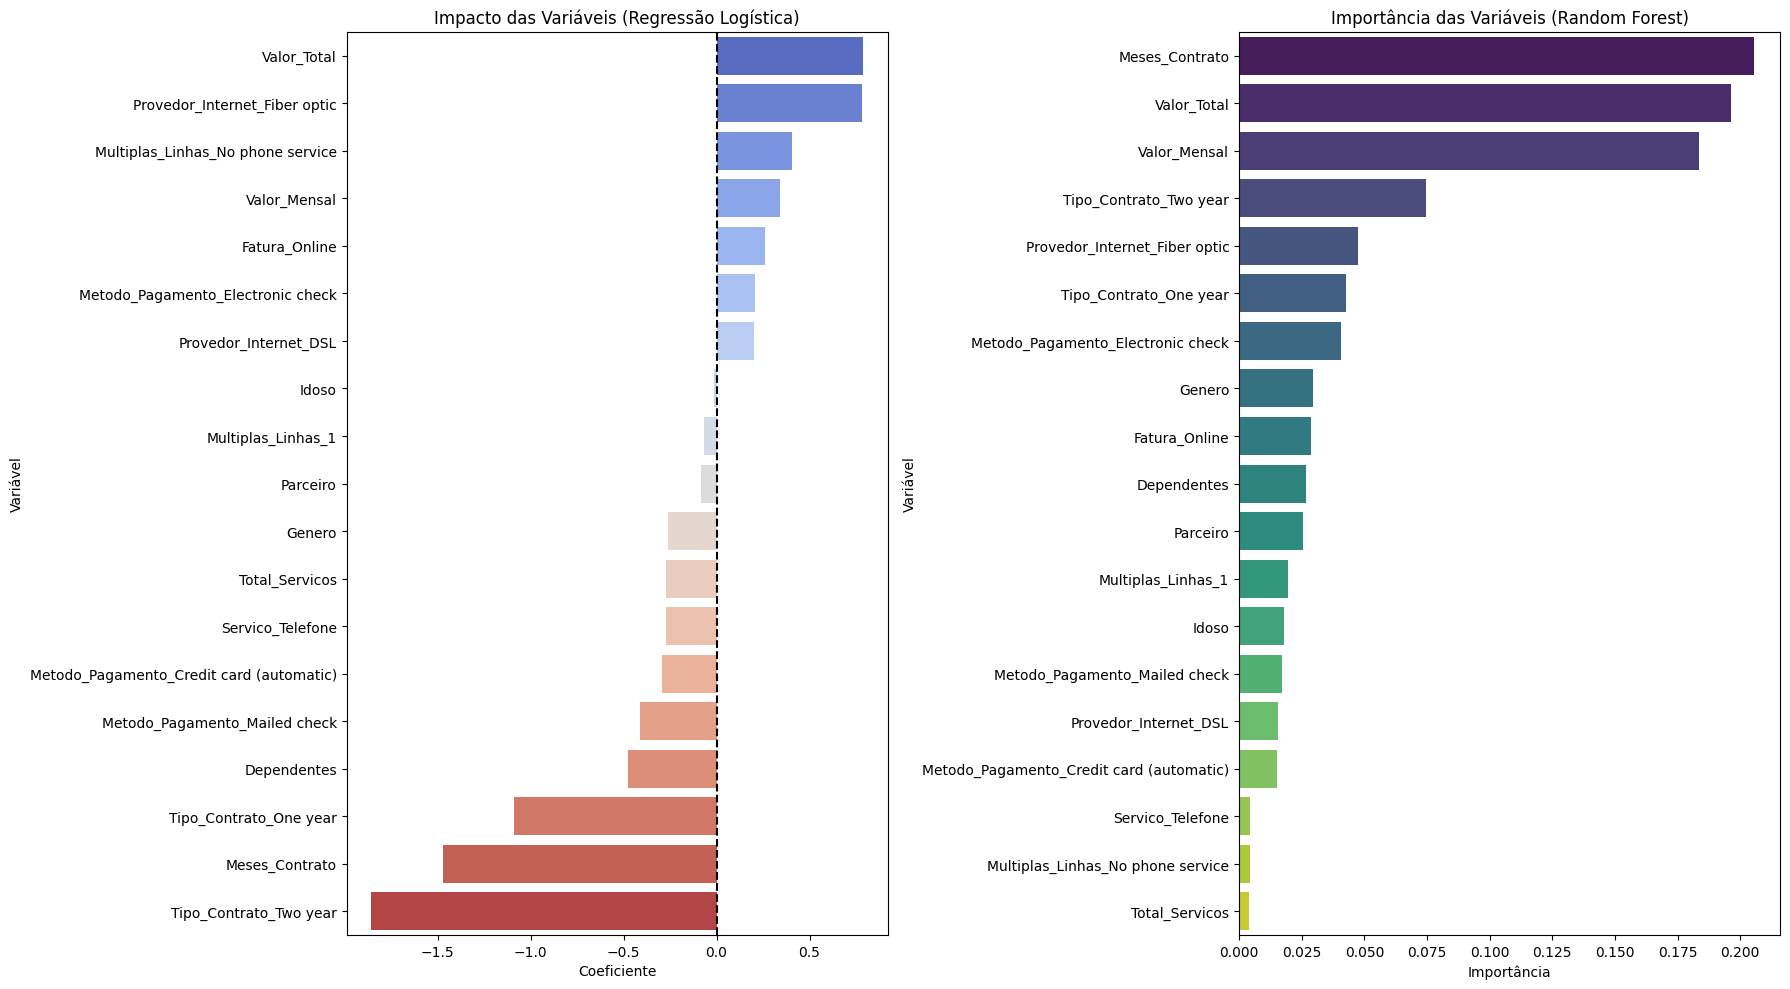

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para evitar o erro de tamanho, usamos as colunas do X_train (o que o modelo de fato viu)
colunas_treino = X_train.columns

# 1. Extraindo Coeficientes da Regressão Logística
importancia_log = pd.DataFrame({
    'Variável': colunas_treino,
    'Coeficiente': model_log_bal.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# 2. Extraindo Importância do Random Forest
# Usamos o modelo treinado com SMOTE para a comparação ser justa
importancia_rf = pd.DataFrame({
    'Variável': colunas_treino,
    'Importância': model_rf_bal.feature_importances_
}).sort_values(by='Importância', ascending=False)

# 3. Visualização Gráfica
fig, ax = plt.subplots(1, 2, figsize=(18, 10))

# Plot Regressão Logística
sns.barplot(x='Coeficiente', y='Variável', data=importancia_log, ax=ax[0], palette='coolwarm')
ax[0].set_title('Impacto das Variáveis (Regressão Logística)')
ax[0].axvline(0, color='black', linestyle='--')

# Plot Random Forest
sns.barplot(x='Importância', y='Variável', data=importancia_rf, ax=ax[1], palette='viridis')
ax[1].set_title('Importância das Variáveis (Random Forest)')

plt.tight_layout()
plt.show()

### Análise dos Gatilhos de Evasão

A análise dos coeficientes da Regressão Logística e da importância das variáveis no Random Forest permite identificar os principais fatores associados à evasão de clientes.

#### 1. Contratos de Longo Prazo como Fator de Retenção

As variáveis `Tipo_Contrato_Two year` e `Tipo_Contrato_One year` apresentam coeficientes negativos expressivos, indicando que **contratos de longo prazo reduzem significativamente a probabilidade de evasão**.

Isso implica que clientes que não possuem esses contratos — ou seja, aqueles no modelo **mês a mês** — ficam mais expostos ao churn. Sem o compromisso de fidelidade, esse grupo apresenta maior flexibilidade para cancelar o serviço, tornando-se o segmento de maior risco.

#### 2. Fibra Óptica e Impacto do Custo do Serviço

A variável `Provedor_Internet_Fiber optic` aparece com um dos maiores coeficientes positivos, sugerindo maior propensão à evasão entre clientes desse tipo de serviço. Esse comportamento pode estar relacionado a **custos mais elevados** ou possíveis problemas de **qualidade ou estabilidade do serviço**.

Além disso, `Valor_Mensal` e `Valor_Total` também aparecem entre os fatores mais relevantes nos dois modelos. Isso indica que o **peso financeiro da assinatura** exerce forte influência na decisão de cancelamento, especialmente quando as faturas são mais altas.

#### 3. Tempo de Relacionamento com a Empresa

No modelo Random Forest, `Meses_Contrato` surge como a variável mais importante para explicar o churn. Esse resultado reforça o padrão observado anteriormente nas análises exploratórias: **os primeiros meses do cliente são o período mais crítico**.

Clientes que permanecem por mais tempo tendem a desenvolver maior vínculo com o serviço, reduzindo significativamente a probabilidade de cancelamento.

# Relatório de Conclusão: Predição de Churn – Telecom X

Este documento apresenta os resultados finais do projeto de Ciência de Dados voltado para a **redução da evasão de clientes (Churn)**.  
A partir da análise de dados históricos e da aplicação de modelos de **Machine Learning**, foram identificados padrões relevantes e propostas ações estratégicas para retenção de clientes.

---

# 1. Desempenho dos Modelos e Metodologia

Durante o desenvolvimento do projeto, diferentes algoritmos e técnicas de pré-processamento foram avaliados. A base de dados apresentava um **desbalanceamento natural**, com aproximadamente **26,5% de clientes que cancelaram o serviço**, o que exigiu a aplicação da técnica **SMOTE** para equilibrar as classes durante o treinamento.

### Comparação de Modelos

| Modelo | Acurácia | Precisão (Evasão) | Recall (Evasão) | F1-Score |
|---|---|---|---|---|
| Regressão Logística (Base) | 0.81 | 0.68 | 0.56 | 0.62 |
| Random Forest (SMOTE) | 0.76 | 0.53 | 0.61 | 0.57 |
| Regressão Logística (SMOTE) | 0.75 | 0.52 | 0.80 | 0.63 |

### Escolha Técnica

O modelo **Regressão Logística com SMOTE** foi selecionado como solução final.  
Apesar de apresentar uma acurácia ligeiramente menor, ele possui o **maior Recall (0.80)**, sendo capaz de identificar **80% dos clientes com risco de evasão**.

Do ponto de vista do negócio, **perder um cliente ativo gera um custo muito maior do que abordar um cliente que talvez não cancelaria**, tornando o Recall a métrica mais estratégica neste contexto.

---

# 2. Fatores Influenciadores da Evasão

A análise de importância das variáveis revelou três fatores principais que influenciam o comportamento de cancelamento dos clientes.

### Tipo de Contrato

Clientes com **contratos mensais** apresentam maior propensão à evasão.  
Já os contratos de **1 ano ou 2 anos** funcionam como **âncoras de retenção**, reduzindo significativamente o risco de churn.

### Serviços de Internet (Fibra Óptica)

Clientes que utilizam **Fibra Óptica** apresentam taxas de cancelamento superiores às observadas em usuários de **DSL**.  

Esse padrão pode indicar:
- problemas na **percepção de custo-benefício**
- possíveis **instabilidades técnicas**
- maior sensibilidade ao valor do serviço.

### Tempo de Relacionamento (Tenure)

Os **primeiros 12 meses** representam a fase de maior risco de evasão.

Clientes que permanecem além desse período tendem a:
- desenvolver maior vínculo com o serviço
- apresentar menor probabilidade de cancelamento.

---

# 3. Estratégias de Retenção Propostas

Com base nos padrões identificados nos dados, são propostas três estratégias principais para redução do churn.

## Plano de Blindagem Contratual

**Ação:**  
Implementar campanhas de migração do plano mensal para planos anuais, oferecendo incentivos progressivos, como:
- 1 mês gratuito
- upgrade de velocidade
- descontos por fidelidade.

**Objetivo:**  
Aumentar a barreira de saída para clientes atualmente sem compromisso de longo prazo.

---

## Programa de Qualidade da Fibra Óptica

**Ação:**  
Realizar auditorias técnicas nos clusters de clientes de fibra com maiores taxas de evasão e revisar a política de preços do serviço.

**Objetivo:**  
Reduzir a saída de clientes que utilizam o **produto de maior valor agregado da empresa**.

---

## Monitoramento do Primeiro Ano de Cliente

**Ação:**  
Implementar uma régua de relacionamento automatizada para novos clientes, incluindo pesquisas de satisfação (**NPS**) no:

- 3º mês  
- 6º mês  
- 9º mês

**Objetivo:**  
Identificar pontos de atrito de forma precoce e garantir que o cliente supere a fase inicial mais crítica.

---

# 4. Conclusão

A utilização de **análise de dados e Machine Learning** permitiu à Telecom X evoluir de uma postura **reativa** para uma estratégia **proativa de retenção de clientes**.

Com o modelo desenvolvido, a empresa passa a ter capacidade técnica de **identificar aproximadamente 8 em cada 10 clientes com risco de cancelamento**, permitindo intervenções antecipadas para:

- reduzir perdas de receita
- aumentar o tempo de relacionamento com o cliente
- maximizar o **Lifetime Value (LTV)** da base de clientes.